In [2]:
import pandas as pd
import numpy as np


def weight_sensitivity(lang: str):
    prefix = {"Java": "java", "Python": "py"}
    feature_cols = {
        "Java": ["class_sim", "method_sim", "arg_sim"],
        "Python": ["fqn_sim", "arg_sim"],
    }
    evaluation_results = pd.read_csv(
        f"../benchmark/evaluation/{prefix[lang]}_weight_analysis.csv"
    )
    feature_col = feature_cols[lang]
    summary = evaluation_results.groupby(feature_col, as_index=False).agg(
        f1_mean=("f1", "mean"), f1_std=("f1", "std")
    )
    equal_weight_mask = np.isclose(summary[feature_col[0]], 1 / len(feature_col))
    equal_row = summary[equal_weight_mask]
    equal_weight_f1 = equal_row.iloc[0, -2]
    print("Java: ")
    print(
        f"    Equal_weights: F1: {equal_weight_f1*100:.1f}, STD: {equal_row.iloc[0, -1]}"
    )
    min_f1_row = summary[summary["f1_mean"] == summary["f1_mean"].min()]
    min_f1, min_std = min_f1_row.iloc[0, -2], min_f1_row.iloc[0, -1]
    min_config = min_f1_row.iloc[0, :-2].values
    print(f"    Min: {min_config}, F1: {min_f1*100:.1f}, STD: {min_std}")
    max_f1_row = summary[summary["f1_mean"] == summary["f1_mean"].max()]
    max_f1, max_std = max_f1_row.iloc[0, -2], max_f1_row.iloc[0, -1]
    max_config = max_f1_row.iloc[0, :-2].values
    print(f"    Max: {max_config}, F1: {max_f1*100:.1f}, STD: {max_std}")

    # return pd.concat([equal_row, min_f1_row, max_f1_row])


weight_sensitivity("Java")
weight_sensitivity("Python")

Java: 
    Equal_weights: F1: 89.9, STD: 0.05512525022535133
    Min: [0.2 0.1 0.7], F1: 86.7, STD: 0.05937863588371544
    Max: [0.33333333 0.33333333 0.33333333], F1: 89.9, STD: 0.05512525022535133
Java: 
    Equal_weights: F1: 73.1, STD: 0.04391418796046915
    Min: [0.7 0.3], F1: 72.4, STD: 0.065231750963834
    Max: [0.6 0.4], F1: 73.7, STD: 0.04461468354780539


In [3]:
import pandas as pd
import numpy as np


def construct_heatmap():
    evaluation_results = pd.read_csv("../benchmark/evaluation/java_weight_analysis.csv")
    feature_col = ["class_sim", "method_sim", "arg_sim"]
    summary = evaluation_results.groupby(feature_col, as_index=False).agg(
        f1_mean=("f1", "mean"), f1_std=("f1", "std")
    )
    equal_weight_mask = np.isclose(summary[feature_col[0]], 1 / len(feature_col))
    summary = summary[~equal_weight_mask]
    cs_values = sorted(summary["class_sim"].unique())
    ms_values = sorted(summary["method_sim"].unique(), reverse=True)
    heatmap = summary.pivot(
        index="method_sim", columns="class_sim", values="f1_mean"
    ).reindex(index=ms_values, columns=cs_values)
    std_heatmap = summary.pivot(
        index="method_sim", columns="class_sim", values="f1_std"
    ).reindex(index=ms_values, columns=cs_values)
    values = heatmap.to_numpy(dtype=float)
    std_values = std_heatmap.to_numpy(dtype=float)
    masked_values = np.ma.masked_invalid(values)

    return cs_values, ms_values, values, masked_values, std_values

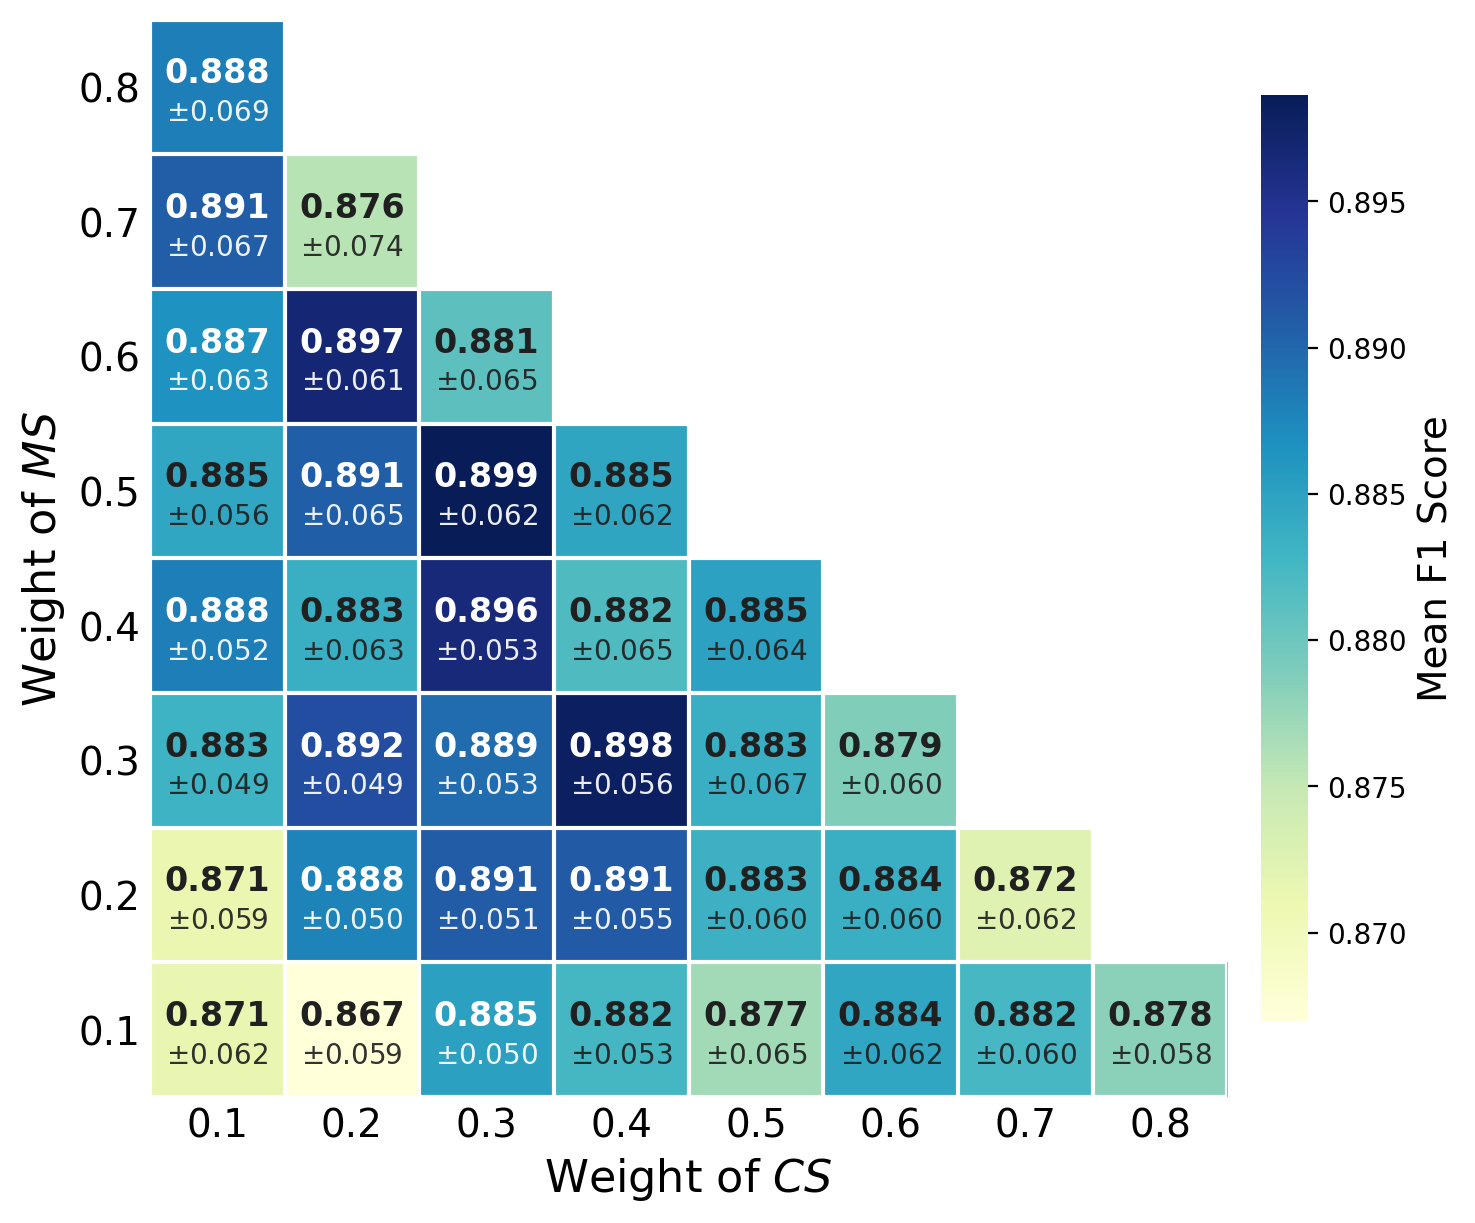

In [50]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import matplotlib.pyplot as plt


def plot_java_sensitivity(save_path: str | None = None):
    cs_values, ms_values, values, masked_values, std_values = construct_heatmap()
    fig, ax = plt.subplots(figsize=(8.0, 6), constrained_layout=True)
    cmap = plt.colormaps["YlGnBu"].copy()
    cmap.set_bad("white")
    image = ax.imshow(masked_values, cmap=cmap, aspect="equal", interpolation="none")

    normalizer = plt.Normalize(np.nanmin(values), np.nanmax(values))
    for row in range(values.shape[0]):
        for col in range(values.shape[1]):
            value = values[row, col]
            if np.isnan(value):
                continue
            text_color = "white" if normalizer(value) > 0.57 else "#202020"
            ax.text(
                col,
                row - 0.10,
                f"{value:.3f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=12,
                fontweight="semibold",
            )
            ax.text(
                col,
                row + 0.19,
                rf"$\pm${std_values[row, col]:.3f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=10,
                alpha=0.92,
            )

    ax.set_xticks(
        np.arange(len(cs_values)), [f"{value:.1f}" for value in cs_values], fontsize=14
    )
    ax.set_yticks(
        np.arange(len(ms_values)), [f"{value:.1f}" for value in ms_values], fontsize=14
    )
    ax.set_xticks(np.arange(-0.5, len(cs_values), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ms_values), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(axis="both", which="both", length=0)
    ax.set_xlabel(r"Weight of $CS$", fontsize=16)
    ax.set_ylabel(r"Weight of $MS$", fontsize=16)
    for spine in ax.spines.values():
        spine.set_visible(False)
    # ax.set_title(r"Java Weight Sensitivity ($w_{AS_j}=1-w_{CS}-w_{MS}$)", pad=12)
    colorbar = fig.colorbar(image, ax=ax, shrink=0.86, pad=0.025)
    colorbar.set_label("Mean F1 Score", fontsize=14)
    colorbar.outline.set_visible(False)
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")


plot_java_sensitivity("../submission/figures/rq2_java_weight_sensitivity.pdf")

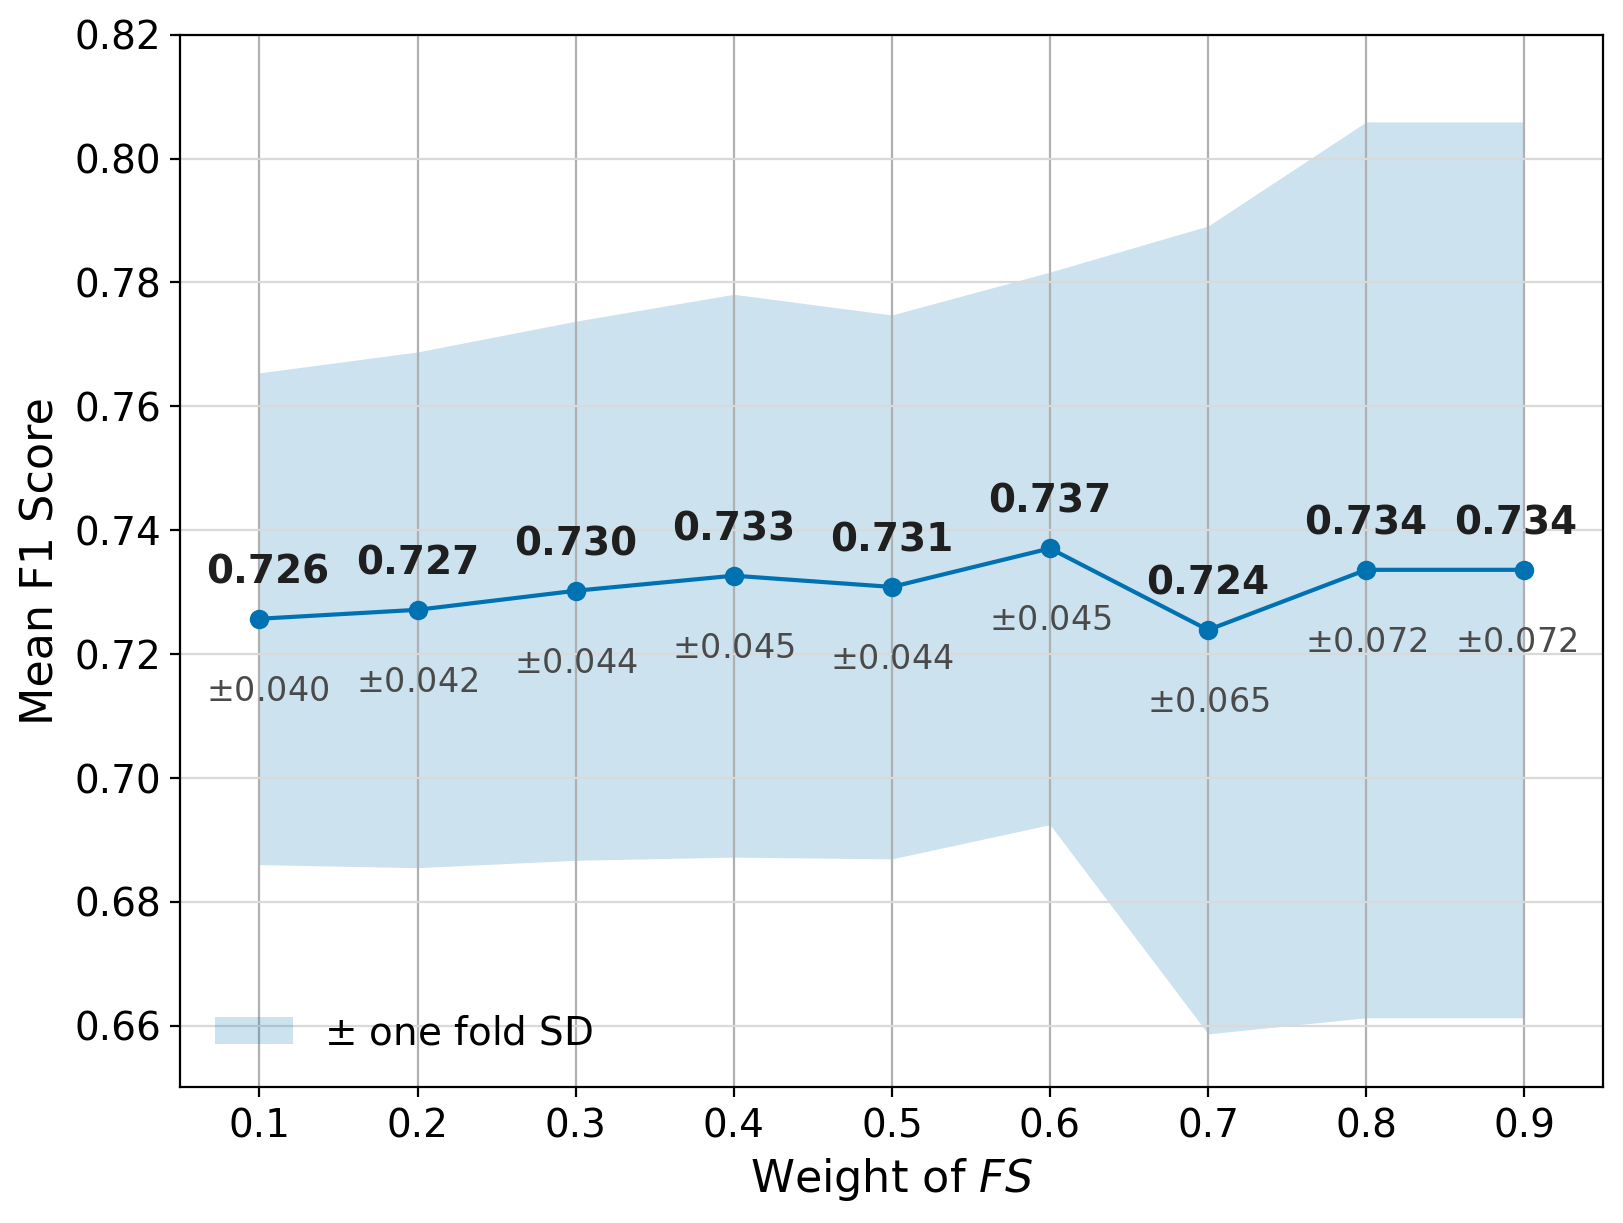

In [48]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np


def plot_python_sensitivity(save_path: str | None = None):
    weights = pd.read_csv("../benchmark/evaluation/py_weight_analysis.csv")
    summary = (
        weights.groupby(["fqn_sim", "arg_sim"], as_index=False)
        .agg(f1_mean=("f1", "mean"), f1_std=("f1", "std"))
        .sort_values("fqn_sim")
    )

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    color = "#0072B2"
    ax.plot(summary["fqn_sim"], summary["f1_mean"], color=color, marker="o")
    ax.fill_between(
        summary["fqn_sim"],
        summary["f1_mean"] - summary["f1_std"],
        summary["f1_mean"] + summary["f1_std"],
        color=color,
        alpha=0.2,
        linewidth=0,
        label=r"$\pm$ one fold SD",
    )
    for point in summary.itertuples(index=False):
        if point.fqn_sim <= 0.1:
            horizontal_alignment, horizontal_offset = "center", 3
        elif point.fqn_sim >= 0.9:
            horizontal_alignment, horizontal_offset = "center", -3
        else:
            horizontal_alignment, horizontal_offset = "center", 0
        ax.annotate(
            f"{point.f1_mean:.3f}",
            (point.fqn_sim, point.f1_mean),
            xytext=(horizontal_offset, 10),
            textcoords="offset points",
            ha=horizontal_alignment,
            va="bottom",
            fontsize=14,
            color="#1F1F1F",
            fontweight="semibold",
        )
        ax.annotate(
            rf"$\pm${point.f1_std:.3f}",
            (point.fqn_sim, point.f1_mean),
            xytext=(horizontal_offset, -20),
            textcoords="offset points",
            ha=horizontal_alignment,
            va="top",
            fontsize=12,
            color="#4A4A4A",
        )
    ax.set_xlim(0.05, 0.95)
    ax.set_ylim(0.65, 0.82)
    ax.set_xticks(np.arange(0.1, 1.0, 0.1))
    ax.tick_params(axis="both", labelsize=14)
    # ax.set_yticks(np.arange(0.5, 1.01, 0.1))
    ax.set_xlabel(r"Weight of $FS$", fontsize=16)
    ax.set_ylabel("Mean F1 Score", fontsize=16)
    ax.grid()
    # ax.set_title("Python Weight Sensitivity", pad=12)
    ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
    ax.legend(loc="lower left", frameon=False, fontsize=14)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")


plot_python_sensitivity("../submission/figures/rq2_python_weight_sensitivity.pdf")

In [ ]:
def threshold_sensitivity():
    data_map = {
        "Java": pd.read_csv("../benchmark/evaluation/java_threshold_ablation.csv"),
        "Python": pd.read_csv("../benchmark/evaluation/py_threshold_ablation.csv"),
    }
    thresholds = {"Java": 0.45, "Python": 0.35}
    res = []
    for lang in ["Java", "Python"]:
        data = data_map[lang]
        data = data[data["Phase4"]][["threshold", "f1", "precision", "recall"]]
        row1 = data[data["threshold"] == 0.0]
        row2 = data[data["threshold"] == thresholds[lang]]
        row3 = data[data["f1"] == data["f1"].max()]
        tmp = pd.concat([row1, row2, row3])
        tmp["Language"] = lang
        res.append(tmp)
    return pd.concat(res)


threshold_sensitivity()

,threshold,f1,precision,recall,Language
0,0.00,0.874652,0.839572,0.912791,Java
9,0.45,0.901034,0.915916,0.886628,Java
9,0.45,0.901034,0.915916,0.886628,Java
0,0.00,0.734234,0.806931,0.673554,Python
7,0.35,0.748792,0.901163,0.640496,Python
5,0.25,0.750000,0.873626,0.657025,Python
6,0.30,0.750000,0.873626,0.657025,Python


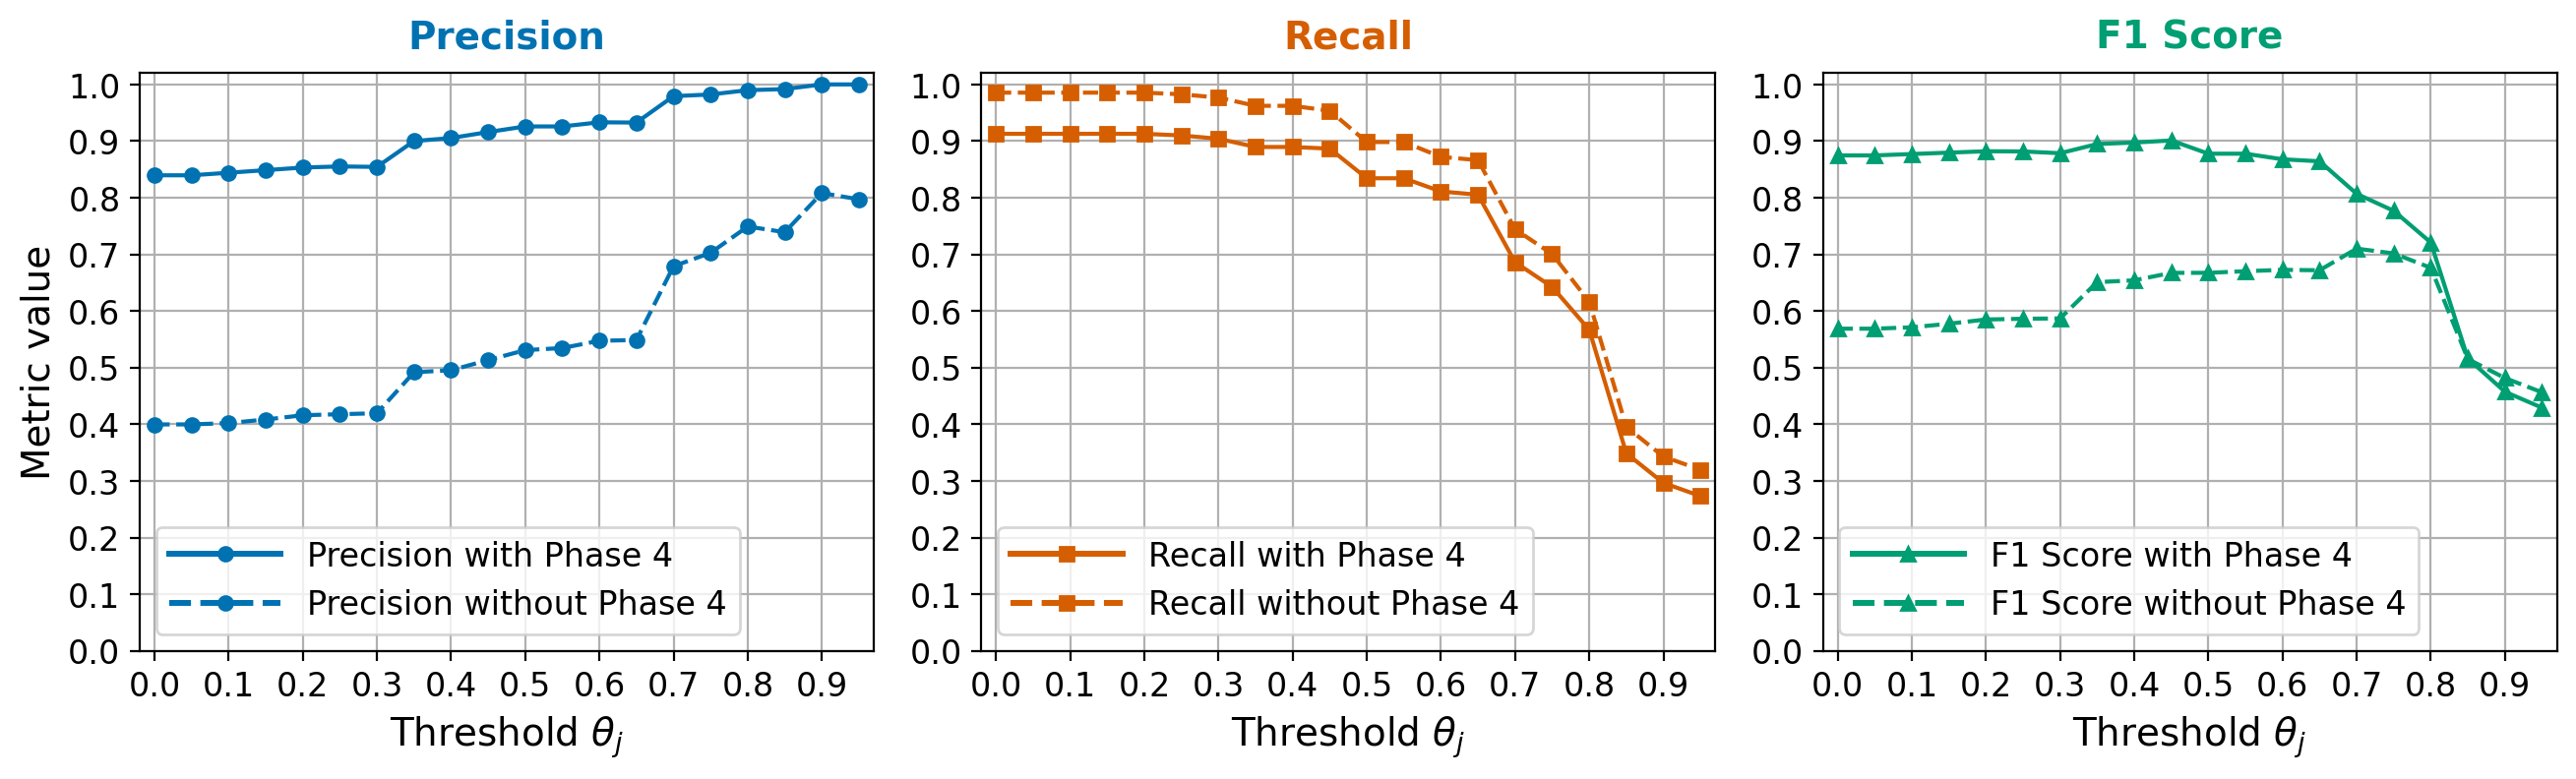

In [44]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import pandas as pd
import matplotlib.pyplot as plt

METRICS = {
    "precision": {"label": "Precision", "color": "#0072B2", "marker": "o"},
    "recall": {"label": "Recall", "color": "#D55E00", "marker": "s"},
    "f1": {"label": "F1 Score", "color": "#009E73", "marker": "^"},
}
PHASE_STYLES = {
    True: ("With Phase 4", "-"),
    False: ("Without Phase 4", "--"),
}


def plot_threshold_ablation(language, save_path: str | None = None):
    if language == "Java":
        data = pd.read_csv("../benchmark/evaluation/java_threshold_ablation.csv")
    elif language == "Python":
        data = pd.read_csv("../benchmark/evaluation/py_threshold_ablation.csv")
    # At threshold 1.0 no pair can satisfy score > threshold, so precision is undefined.
    plot_data = data[data["threshold"] < 1.0].copy()
    fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.1))

    for ax, (metric, style) in zip(axes, METRICS.items()):
        for phase4, (_, linestyle) in PHASE_STYLES.items():
            subset = plot_data[plot_data["Phase4"] == phase4].sort_values("threshold")
            condition = "with Phase 4" if phase4 else "without Phase 4"
            ax.plot(
                subset["threshold"],
                subset[metric],
                color=style["color"],
                linestyle=linestyle,
                marker=style["marker"],
                markersize=5.0,
                # markevery=2,
                # markerfacecolor="white",
                # markeredgewidth=1.3,
                # linewidth=2.15,
                label=f"{style['label']} {condition}",
            )
        ax.set_title(
            style["label"],
            color=style["color"],
            pad=9,
            fontweight="semibold",
            fontsize=14,
        )
        ax.set_xlim(-0.02, 0.97)
        ax.set_ylim(0, 1.02)
        ax.set_xticks(np.arange(0, 0.96, 0.1))
        ax.set_yticks(np.arange(0, 1.01, 0.1))
        if language == "Java":
            xlabel = "Threshold $\\theta_j$"
        elif language == "Python":
            xlabel = "Threshold $\\theta_p$"
        ax.set_xlabel(xlabel, fontsize=14)
        ax.grid()
        # ax.spines["top"].set_visible(False)
        # ax.spines["right"].set_visible(False)
        ax.tick_params(axis="y", labelleft=True)
        ax.tick_params(axis="both", labelsize=12)
        legend_handles = [
            Line2D(
                [0],
                [0],
                color=style["color"],
                linestyle=linestyle,
                marker=style["marker"],
                markersize=5.0,
                linewidth=2.15,
                label=f"{style['label']} {'with Phase 4' if phase4 else 'without Phase 4'}",
            )
            for phase4, (_, linestyle) in PHASE_STYLES.items()
        ]
        ax.legend(
            handles=legend_handles, loc="lower left", fontsize=12, handlelength=3.4
        )

    axes[0].set_ylabel("Metric value", fontsize=14)
    plt.tight_layout()
    plt.show()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")


plot_threshold_ablation("Java", "../submission/figures/rq2_java_threshold_phase4.pdf")

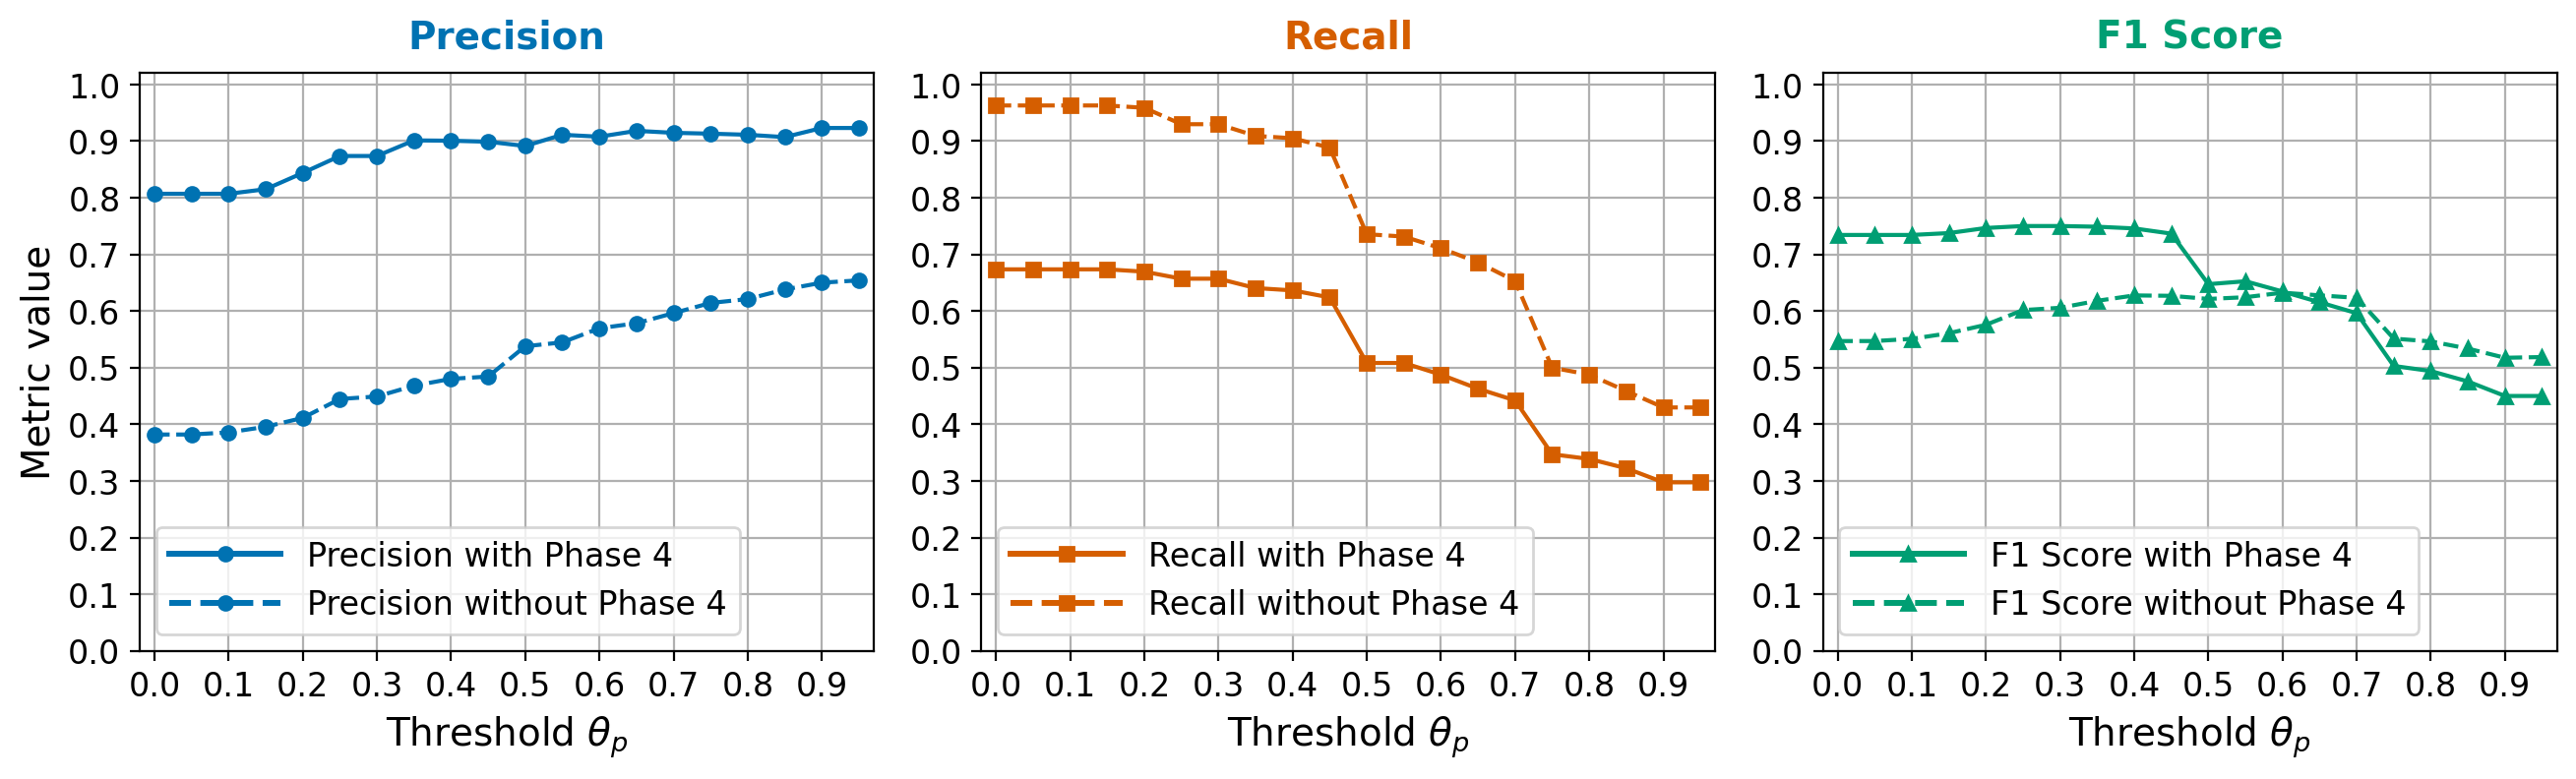

In [45]:
plot_threshold_ablation(
    "Python", "../submission/figures/rq2_python_threshold_phase4.pdf"
)

In [ ]:
def phase4_ablation_analysis():
    data_map = {
        "Java": pd.read_csv("../benchmark/evaluation/java_threshold_ablation.csv"),
        "Python": pd.read_csv("../benchmark/evaluation/py_threshold_ablation.csv"),
    }
    thresholds = {"Java": 0.45, "Python": 0.35}
    res = []
    metrics = ["f1", "precision", "recall"]
    for lang in ["Java", "Python"]:
        data = data_map[lang]
        data = data[data["threshold"] == thresholds[lang]][
            ["Phase4", "f1", "precision", "recall"]
        ]
        data_p4 = data[data["Phase4"]][metrics].iloc[0]
        data_wo_p4 = data[~data["Phase4"]][metrics].iloc[0]
        tmp = pd.DataFrame(
            {
                "With Phase4": data_p4,
                "Without Phase4": data_wo_p4,
                "Diff": data_p4 - data_wo_p4,
            }
        ).T.reset_index()
        tmp["Language"] = lang
        res.append(tmp)
    res = pd.concat(res)
    return (
        res.pivot(index="index", columns="Language", values=metrics)
        .swaplevel(0, 1, axis=1)
        .reindex(
            columns=pd.MultiIndex.from_product(
                [["Java", "Python"], ["precision", "recall", "f1"]],
                names=["Language", "Metric"],
            )
        )
        .iloc[[1, 2, 0]]
    )


phase4_ablation_analysis()

Language            Java                        Python                    
Metric         precision    recall        f1 precision    recall        f1
index                                                                     
With Phase4     0.915916  0.886628  0.901034  0.901163  0.640496  0.748792
Without Phase4  0.513302  0.953488  0.667345  0.468085  0.909091  0.617978
Diff            0.402614 -0.066860  0.233689  0.433078 -0.268595  0.130815